# ECG Binary Classification Project

## Goal

This notebook prepares an ECG dataset for binary classification of `Healthy_Status`, applies dimensionality reduction techniques (`PCA` and `t-SNE`), trains a baseline classifier, and then applies an AutoML framework to select the best model automatically.

## Main steps

1. Load the dataset from a local CSV file if available, otherwise use the public URL.
2. Keep the first 5000 rows.
3. Select the required ECG columns.
4. Replace coded invalid values (`29999`, `32767`) with missing values.
5. Drop incomplete rows.
6. Standardize the numerical features.
7. Apply PCA and t-SNE for visual analysis.
8. Train a baseline Random Forest classifier.
9. Apply PyCaret AutoML and compare models using the F1-score.
10. Evaluate the selected model using confusion matrix and F1-score.

## Environment note

This project is designed to run locally in Jupyter Notebook or VS Code Jupyter.

Recommended steps before running:

1. Create and activate a virtual environment.
2. Install the packages from `requirements.txt`.
3. Put the dataset file in the same folder as this notebook and name it `ecg_dataset.csv`.

If the local file is not found, the notebook will try to load the dataset from the public GitHub raw URL.

In [1]:
# Core imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## Data loading

The notebook first looks for a local file named `ecg_dataset.csv`.  
If the file is not found, it loads the dataset from the public GitHub raw URL.

In [2]:
# Data source configuration
LOCAL_DATASET = Path("ecg_dataset.csv")
DATA_URL = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"

if LOCAL_DATASET.exists():
    df = pd.read_csv(LOCAL_DATASET)
    print("Dataset loaded from local file:", LOCAL_DATASET.resolve())
else:
    df = pd.read_csv(DATA_URL)
    print("Dataset loaded from URL.")

display(df.head())
print("Original dataset shape:", df.shape)

Dataset loaded from URL.


,subject_id,Count_subj,study_id,cart_id,Healthy_Status,eeg_time,eeg_date,report_0,report_1,report_2,...,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
0,19557662,27,40000017,6848296,0,8:44 AM,27.06.2015,Sinus rhythm,Possible right atrial abnormality,NaN,...,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79
1,18477137,93,40000029,6848296,0,9:54 AM,27.06.2015,Sinus rhythm,Possible right atrial abnormality,NaN,...,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70
2,16598616,3,40000035,6376932,1,9:07 AM,28.06.2015,Sinus tachycardia,NaN,Normal ECG except for rate,...,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77
3,16368287,7,40000079,6214760,1,5:14 PM,15.07.2015,Sinus rhythm,NaN,Normal ECG,...,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69
4,18370366,2,40000084,6632385,0,1:52 PM,27.09.2015,Sinus rhythm,NaN,NaN,...,<not specified>,659,368,29999,504,590,868,84,80,77


Original dataset shape: (10000, 36)


## Selecting the required rows and columns

According to the assignment, we keep the first 5000 rows and only the following columns:

- `Count_subj`
- `rr_interval`
- `p_end`
- `qrs_onset`
- `qrs_end`
- `p_axis`
- `qrs_axis`
- `t_axis`
- `Healthy_Status`

In [3]:
# Keep only the first 5000 rows
df = df.iloc[:5000].copy()

# Keep only the required columns
selected_columns = [
    'Count_subj',
    'rr_interval',
    'p_end',
    'qrs_onset',
    'qrs_end',
    'p_axis',
    'qrs_axis',
    't_axis',
    'Healthy_Status'
]
df = df[selected_columns].copy()

display(df.head())
print("Dataset shape after selecting rows and columns:", df.shape)

,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,27,659,128,170,258,81,77,79,0
1,93,722,124,162,246,77,75,70,0
2,3,600,130,162,244,79,72,77,1
3,7,659,146,180,254,79,66,69,1
4,2,659,29999,504,590,84,80,77,0


Dataset shape after selecting rows and columns: (5000, 9)


## Handling coded invalid values

The dataset contains repeated coded values such as `29999` and `32767`.  
These values are treated as invalid placeholders, converted to `NaN`, and then removed.

In [4]:
# Replace coded invalid values with NaN
df_clean = df.replace([29999, 32767], np.nan)

print("Missing values after replacing coded invalid values:")
print(df_clean.isnull().sum())

print("\nShape before dropping missing rows:", df_clean.shape)

# Drop rows containing missing values
df_clean = df_clean.dropna().copy()

print("Shape after dropping missing rows:", df_clean.shape)
display(df_clean.head())

Missing values after replacing coded invalid values:
Count_subj           0
rr_interval         10
p_end             1542
qrs_onset            9
qrs_end             10
p_axis             902
qrs_axis            27
t_axis              35
Healthy_Status       0
dtype: int64

Shape before dropping missing rows: (5000, 9)
Shape after dropping missing rows: (3448, 9)


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,27,659.0,128.0,170.0,258.0,81.0,77.0,79.0,0
1,93,722.0,124.0,162.0,246.0,77.0,75.0,70.0,0
2,3,600.0,130.0,162.0,244.0,79.0,72.0,77.0,1
3,7,659.0,146.0,180.0,254.0,79.0,66.0,69.0,1
6,43,952.0,146.0,198.0,282.0,24.0,80.0,20.0,1


## Splitting features and target

The target variable is already binary (`0` and `1`), so no additional target encoding is required.

In [5]:
# Separate features and target
X = df_clean.drop('Healthy_Status', axis=1)
y = df_clean['Healthy_Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (3448, 8)
Target shape: (3448,)

Target distribution:
Healthy_Status
0    2488
1     960
Name: count, dtype: int64


## Feature scaling

Standardization is applied before PCA, t-SNE, and classification because these methods are sensitive to feature scale.

In [6]:
# Standardize the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("First 5 rows of the scaled features:")
display(X_scaled.head())

First 5 rows of the scaled features:


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis
0,0.361918,-0.900715,-1.106440,-1.064994,-1.016130,1.204029,1.546880,0.718414
1,3.090636,-0.564021,-1.325234,-1.329741,-1.329261,1.067029,1.495897,0.537637
2,-0.630343,-1.216031,-0.997043,-1.329741,-1.381449,1.135529,1.419422,0.678241
3,-0.464967,-0.900715,-0.121866,-0.734061,-1.120507,1.135529,1.266472,0.517550
6,1.023425,0.665179,-0.121866,-0.138381,-0.389869,-0.748212,1.623355,-0.466682


## Principal Component Analysis (PCA)

PCA is used to reduce the dimensionality of the scaled data and inspect the explained variance.

In [7]:
# Fit PCA on the scaled features
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained variance ratio:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)

Explained variance ratio:
[0.29281803 0.14949703 0.13362784 0.12460311 0.11274879 0.08926979
 0.08191141 0.01552399]

Cumulative explained variance:
[0.29281803 0.44231506 0.5759429  0.70054601 0.81329481 0.9025646
 0.98447601 1.        ]


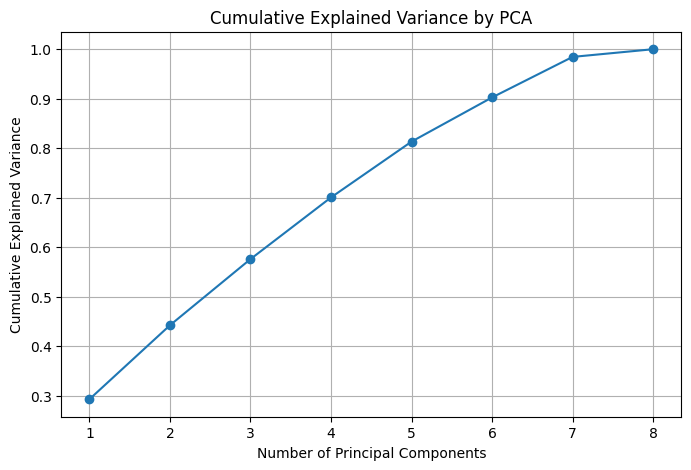

In [8]:
# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA")
plt.grid(True)
plt.show()

In [9]:
# Two-dimensional PCA projection for visualization
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'], index=X.index)
pca_df['Healthy_Status'] = y.values

display(pca_df.head())

,PC1,PC2,Healthy_Status
0,-2.368495,-1.417144,0
1,-2.686436,-0.779678,0
2,-2.757056,-1.446108,1
3,-1.794776,-1.603794,1
6,-0.532443,0.271283,1


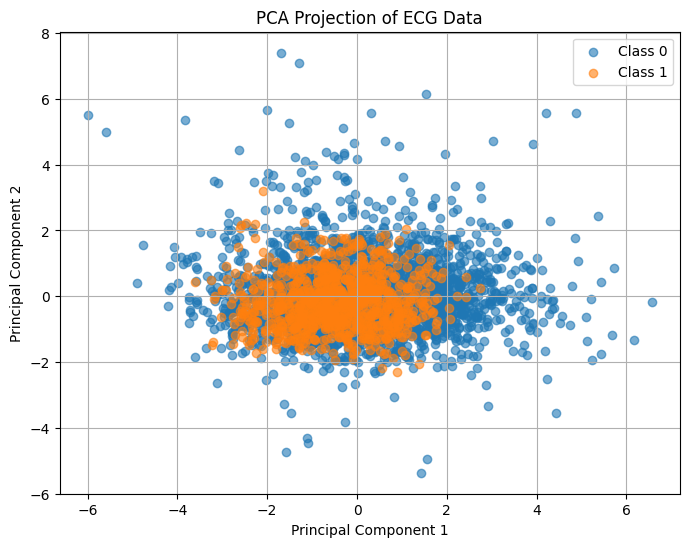

In [10]:
# PCA scatter plot
plt.figure(figsize=(8, 6))
for label in sorted(pca_df['Healthy_Status'].unique()):
    subset = pca_df[pca_df['Healthy_Status'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=f"Class {label}", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of ECG Data")
plt.legend()
plt.grid(True)
plt.show()

## t-SNE visualization

t-SNE is a non-linear dimensionality reduction method used here for visual exploration of the class structure.

In [11]:
# Apply t-SNE for two-dimensional visualization
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=X.index)
tsne_df['Healthy_Status'] = y.values

display(tsne_df.head())

,TSNE1,TSNE2,Healthy_Status
0,-48.189743,-0.094360,0
1,-31.490559,50.413021,0
2,-52.062683,-5.930468,1
3,-38.937767,0.027078,1
6,-14.453081,36.995152,1


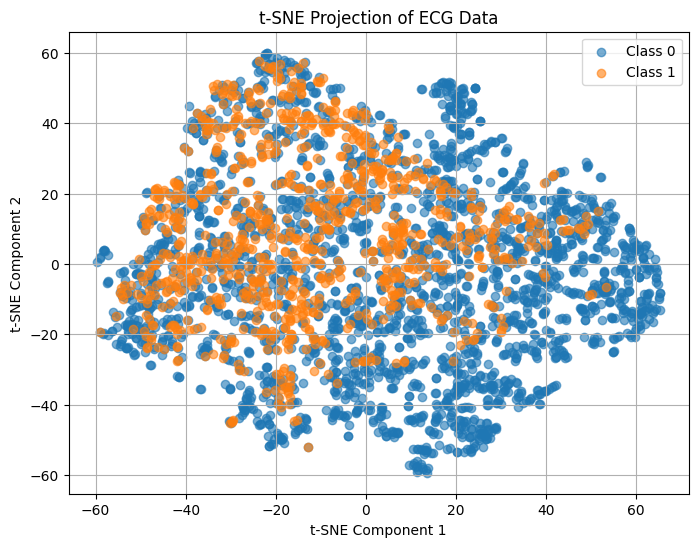

In [12]:
# t-SNE scatter plot
plt.figure(figsize=(8, 6))
for label in sorted(tsne_df['Healthy_Status'].unique()):
    subset = tsne_df[tsne_df['Healthy_Status'] == label]
    plt.scatter(subset['TSNE1'], subset['TSNE2'], label=f"Class {label}", alpha=0.6)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Projection of ECG Data")
plt.legend()
plt.grid(True)
plt.show()

## Train-test split

The cleaned and scaled data is divided into training and testing subsets using a stratified split.

In [13]:
# Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (2758, 8)
Testing set shape: (690, 8)

Training target distribution:
Healthy_Status
0    1990
1     768
Name: count, dtype: int64

Testing target distribution:
Healthy_Status
0    498
1    192
Name: count, dtype: int64


## Baseline classification with Random Forest

A Random Forest classifier is trained as a strong baseline model before applying AutoML.

In [14]:
# Train the baseline Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1-score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8
Random Forest F1-score: 0.6011560693641619

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       498
           1       0.68      0.54      0.60       192

    accuracy                           0.80       690
   macro avg       0.76      0.72      0.73       690
weighted avg       0.79      0.80      0.79       690



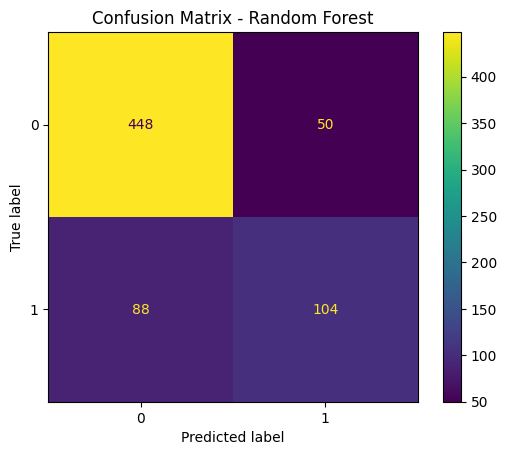

Confusion Matrix:
[[448  50]
 [ 88 104]]


In [15]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

print("Confusion Matrix:")
print(cm_rf)

## AutoML framework selection

In this project, **PyCaret** is used as the AutoML framework because it is easy to use in Jupyter Notebook, supports binary classification, and allows efficient comparison of multiple candidate models using metrics such as accuracy, recall, precision, AUC, and F1-score.

In [16]:
# Import PyCaret classification tools
# Make sure PyCaret is installed using requirements.txt before running this cell.
from pycaret.classification import setup, compare_models, finalize_model, predict_model

## Preparing train and test DataFrames for AutoML

PyCaret expects a single DataFrame containing both features and target.

In [17]:
# Build train and test DataFrames for PyCaret
train_df = X_train.copy()
train_df['Healthy_Status'] = y_train.values

test_df = X_test.copy()
test_df['Healthy_Status'] = y_test.values

print("Train DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)
display(train_df.head())

Train DataFrame shape: (2758, 9)
Test DataFrame shape: (690, 9)


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
1862,-0.588999,0.830854,-0.231263,-0.138381,0.079826,-0.611212,1.368439,-0.205559,1
3660,-0.713032,-0.564021,-0.231263,-0.403128,-0.494246,0.108034,0.399756,-0.346164,1
498,0.113852,-0.975536,-2.200411,0.126365,-0.233304,0.758781,1.215489,0.336773,1
4130,-0.671688,-1.344296,0.643914,-0.601688,-0.807377,0.621781,-0.696385,0.718414,0
1092,1.602244,-0.900715,0.206325,-0.403128,-0.546435,0.347783,1.699830,-0.406423,1


## Running the AutoML experiment

PyCaret compares candidate models and sorts them by the F1-score.

In [18]:
# Initialize the PyCaret experiment on the training data
clf_setup = setup(
    data=train_df,
    target='Healthy_Status',
    session_id=RANDOM_STATE,
    fold=5,
    normalize=False,  # the data is already scaled
    verbose=False
)

# Compare models and choose the best one according to F1
best_model = compare_models(sort='F1')

print("Best AutoML model:")
print(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.7430,0.8325,0.8008,0.5268,0.6346,0.4496,0.4740,0.0080
nb,Naive Bayes,0.7492,0.8236,0.7692,0.5377,0.6319,0.4514,0.4687,0.3240
ada,Ada Boost Classifier,0.7627,0.8432,0.6258,0.5671,0.5944,0.4274,0.4289,0.0220
gbc,Gradient Boosting Classifier,0.7746,0.8520,0.5827,0.5990,0.5895,0.4344,0.4354,0.0440
lightgbm,Light Gradient Boosting Machine,0.7684,0.8457,0.5586,0.5895,0.5720,0.4138,0.4151,0.2460
xgboost,Extreme Gradient Boosting,0.7565,0.8351,0.5457,0.5665,0.5540,0.3870,0.3884,0.1400
knn,K Neighbors Classifier,0.7420,0.7774,0.5643,0.5344,0.5487,0.3683,0.3687,0.3360
rf,Random Forest Classifier,0.7694,0.8455,0.4972,0.6052,0.5454,0.3930,0.3967,0.0440
dt,Decision Tree Classifier,0.7326,0.6769,0.5513,0.5194,0.5341,0.3471,0.3479,0.2760
et,Extra Trees Classifier,0.7715,0.8410,0.4302,0.6335,0.5118,0.3697,0.3819,0.0360


Best AutoML model:
QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                              store_covariance=False, tol=0.0001)


## Finalizing the selected model and evaluating it on the external test set

In [19]:
# Finalize the selected AutoML model
final_model = finalize_model(best_model)

# Generate predictions on the external test set
test_predictions = predict_model(final_model, data=test_df)

display(test_predictions.head())
print(test_predictions.columns)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Quadratic Discriminant Analysis,0.7783,0.8624,0.8281,0.5699,0.6752,0.5154,0.5362


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status,prediction_label,prediction_score
3795,0.155197,-0.034930,0.643914,0.920604,0.653899,0.998530,1.725322,0.658155,0,0,0.5058
2503,-0.464967,0.510193,0.096928,0.589671,0.497334,-0.987961,-0.849335,-0.446596,0,1,0.5924
258,-0.630343,0.360551,-0.450057,-0.270755,-0.650811,0.450532,-1.180726,-0.044868,0,0,0.5724
2411,0.692671,0.093334,-2.419205,0.258738,2.219552,-1.501708,-2.021950,1.079969,0,0,1.0000
4894,-0.506311,-1.119833,-0.997043,-1.726860,-2.007710,-1.741457,-0.976793,-0.285905,1,0,0.9521


Index(['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis',
       'qrs_axis', 't_axis', 'Healthy_Status', 'prediction_label',
       'prediction_score'],
      dtype='object')


In [20]:
# Extract predicted labels from the PyCaret output
if 'prediction_label' in test_predictions.columns:
    y_pred_automl = test_predictions['prediction_label']
elif 'Label' in test_predictions.columns:
    y_pred_automl = test_predictions['Label']
else:
    raise ValueError("Prediction label column not found.")

print("AutoML Accuracy:", accuracy_score(y_test, y_pred_automl))
print("AutoML F1-score:", f1_score(y_test, y_pred_automl))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_automl))

AutoML Accuracy: 0.7782608695652173
AutoML F1-score: 0.6751592356687898

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.76      0.83       498
           1       0.57      0.83      0.68       192

    accuracy                           0.78       690
   macro avg       0.74      0.79      0.75       690
weighted avg       0.82      0.78      0.79       690



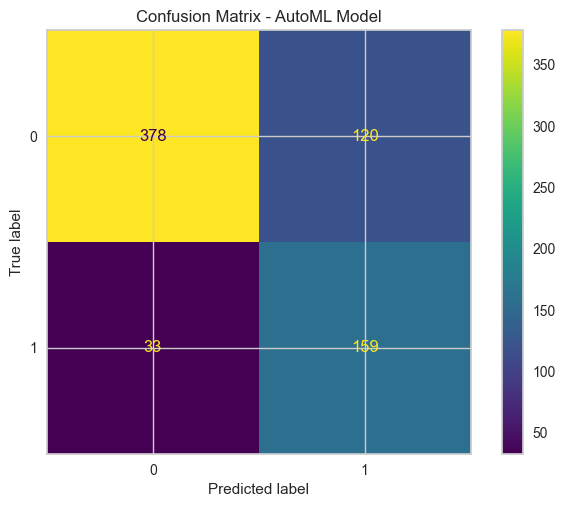

Confusion Matrix:
[[378 120]
 [ 33 159]]


In [21]:
# Confusion matrix for the AutoML-selected model
cm_automl = confusion_matrix(y_test, y_pred_automl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_automl)
disp.plot()
plt.title("Confusion Matrix - AutoML Model")
plt.show()

print("Confusion Matrix:")
print(cm_automl)

## Final conclusion

This notebook completes the required workflow for the ECG binary classification task:

- data loading and preparation
- invalid value handling
- scaling
- PCA
- t-SNE
- baseline classification
- AutoML model selection
- confusion matrix
- F1-score evaluation

For reproducibility, run the notebook from the first cell to the last cell in order.